In [48]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import scipy.stats as st


In [28]:
df_users = pd.read_csv('acc-data/ACC-usagers-2018.csv')
df_acc = pd.read_csv("acc-data/ACC-caracteristiques-2018.csv")

In [29]:
merge = df_acc.merge(df_users , "inner" , on="Num_Acc")
merge

,Num_Acc,an,mois,jour,hrmn,lum,agg,int,atm,col,...,catu,grav,sexe,trajet,secu,locp,actp,etatp,an_nais,num_veh
0,201800000001,18,1,24,1505,1,1,4,1.0,1.0,...,1,3,1,0.0,11.0,0.0,0.0,0.0,1928.0,B01
1,201800000001,18,1,24,1505,1,1,4,1.0,1.0,...,1,1,1,5.0,11.0,0.0,0.0,0.0,1960.0,A01
2,201800000002,18,2,12,1015,1,2,7,7.0,7.0,...,1,1,1,0.0,11.0,0.0,0.0,0.0,1947.0,A01
3,201800000002,18,2,12,1015,1,2,7,7.0,7.0,...,3,4,1,0.0,2.0,2.0,3.0,1.0,1959.0,A01
4,201800000003,18,3,4,1135,1,2,3,1.0,7.0,...,1,3,1,5.0,21.0,0.0,0.0,0.0,1987.0,A01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130164,201800057781,18,12,22,2150,5,2,1,1.0,6.0,...,3,4,1,9.0,3.0,4.0,3.0,1.0,1975.0,A01
130165,201800057782,18,12,23,1945,5,2,1,1.0,1.0,...,1,4,2,9.0,11.0,NaN,NaN,NaN,1993.0,A01
130166,201800057782,18,12,23,1945,5,2,1,1.0,1.0,...,1,4,1,9.0,21.0,NaN,NaN,NaN,1974.0,B01
130167,201800057783,18,12,28,1425,1,2,1,1.0,1.0,...,1,4,1,9.0,11.0,NaN,NaN,NaN,1973.0,B01


In [30]:
df_time = merge[["Num_Acc","hrmn","lum","grav","dep"]]
df_time

,Num_Acc,hrmn,lum,grav,dep
0,201800000001,1505,1,3,590
1,201800000001,1505,1,1,590
2,201800000002,1015,1,1,590
3,201800000002,1015,1,4,590
4,201800000003,1135,1,3,590
...,...,...,...,...,...
130164,201800057781,2150,5,4,976
130165,201800057782,1945,5,4,976
130166,201800057782,1945,5,4,976
130167,201800057783,1425,1,4,976


In [31]:
df_time["hr"] = df_time["hrmn"]
df_time

,Num_Acc,hrmn,lum,grav,dep,hr
0,201800000001,1505,1,3,590,1505
1,201800000001,1505,1,1,590,1505
2,201800000002,1015,1,1,590,1015
3,201800000002,1015,1,4,590,1015
4,201800000003,1135,1,3,590,1135
...,...,...,...,...,...,...
130164,201800057781,2150,5,4,976,2150
130165,201800057782,1945,5,4,976,1945
130166,201800057782,1945,5,4,976,1945
130167,201800057783,1425,1,4,976,1425


In [32]:
def change(x):
    if x == 2:
        return 4
    if x == 4:
        return 2
    if x == 1:
        return 1 
    if x == 3:
        return 3

In [33]:
df_time["grav1"] = df_time["grav"].map(change)
df_time

,Num_Acc,hrmn,lum,grav,dep,hr,grav1
0,201800000001,1505,1,3,590,1505,3
1,201800000001,1505,1,1,590,1505,1
2,201800000002,1015,1,1,590,1015,1
3,201800000002,1015,1,4,590,1015,2
4,201800000003,1135,1,3,590,1135,3
...,...,...,...,...,...,...,...
130164,201800057781,2150,5,4,976,2150,2
130165,201800057782,1945,5,4,976,1945,2
130166,201800057782,1945,5,4,976,1945,2
130167,201800057783,1425,1,4,976,1425,2


In [34]:
time_paris = df_time[df_time["dep"] == 750]
time_lyon = df_time[df_time["dep"] == 690]

In [35]:
time_lyon['hr'] = (time_lyon["hrmn"]/100).astype(int)
time_paris['hr'] = (time_paris["hrmn"]/100).astype(int)

time_lyon

,Num_Acc,hrmn,lum,grav,dep,hr,grav1
3693,201800001654,1755,5,1,690,17,1
3694,201800001654,1755,5,3,690,17,3
3695,201800001655,1845,5,4,690,18,2
3696,201800001655,1845,5,3,690,18,3
3697,201800001655,1845,5,1,690,18,1
...,...,...,...,...,...,...,...
112199,201800049522,1125,1,2,690,11,4
112200,201800049522,1125,1,1,690,11,1
112201,201800049522,1125,1,4,690,11,2
112202,201800049522,1125,1,1,690,11,1


In [36]:
#plt.hist(time_lyon["hr"],weights=time_lyon["grav1"])


In [37]:
#sns.boxplot(data = time_lyon, x="hr",y="grav")
time_lyon = time_lyon.sort_values('hr',ascending=True)
time_lyon

,Num_Acc,hrmn,lum,grav,dep,hr,grav1
108750,201800048210,10,5,1,690,0,1
108751,201800048210,10,5,1,690,0,1
108749,201800048210,10,5,4,690,0,2
40282,201800017789,40,5,3,690,0,3
109305,201800048458,50,5,4,690,0,2
...,...,...,...,...,...,...,...
109998,201800048759,2325,5,4,690,23,2
109999,201800048759,2325,5,4,690,23,2
73033,201800032327,2305,5,3,690,23,3
107124,201800047492,2300,5,4,690,23,2


Text(0.5, 1.0, 'Severity of accident per time of day - Lyon')

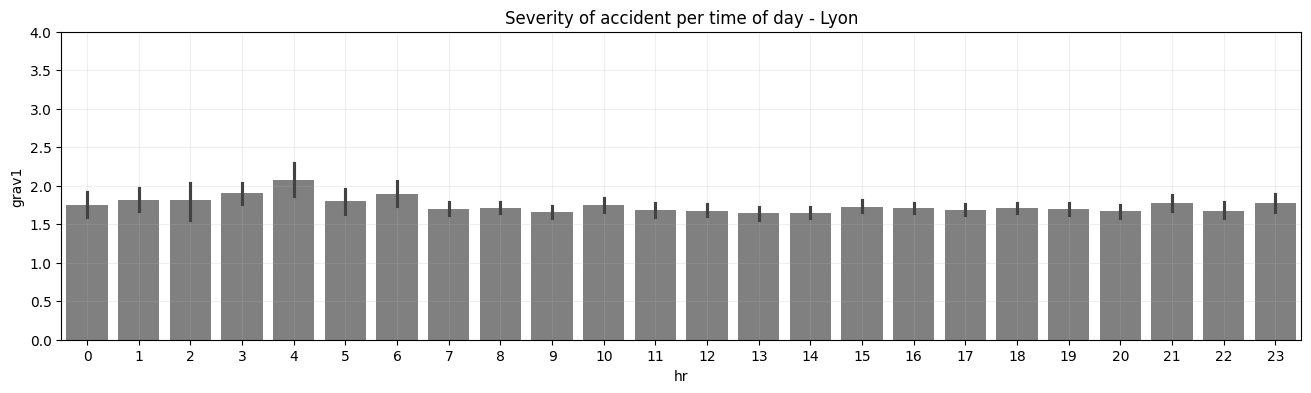

In [38]:
plt.figure(figsize=(16,4))
sns.barplot(data=time_lyon, x="hr", y="grav1",color="gray")
plt.grid(True, alpha=0.2)
plt.ylim(0,4)
plt.title("Severity of accident per time of day - Lyon")

Text(0.5, 1.0, 'Severity of accident per time of day - Paris')

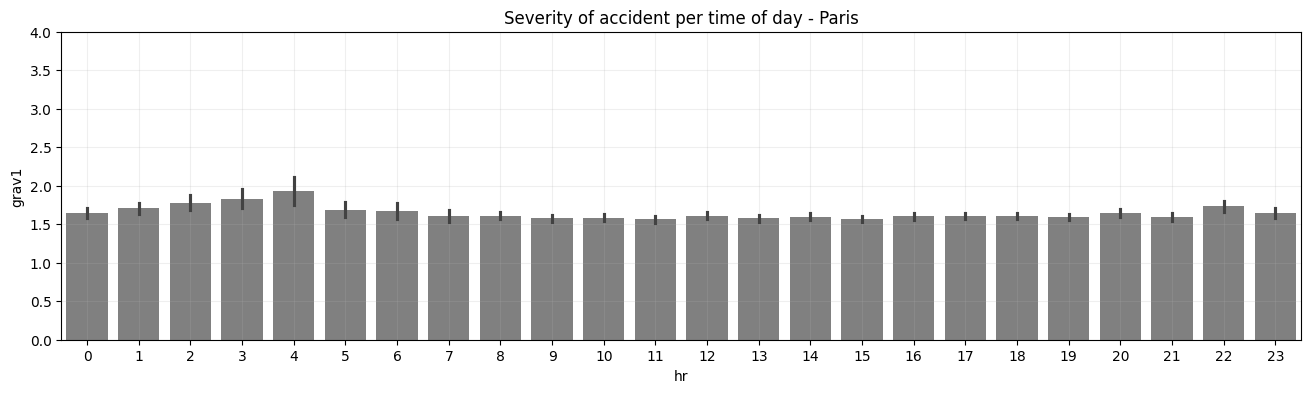

In [39]:
plt.figure(figsize=(16,4))
sns.barplot(data=time_paris, x="hr", y="grav1", color="gray")
plt.grid(True, alpha=0.2)
plt.ylim(0,4)
plt.title("Severity of accident per time of day - Paris")

In [40]:
df = df_time.copy()

df["hour"] = (df["hrmn"] // 100).astype(int)

bins = [0, 6, 10, 14, 18, 22, 24]
labels = ["0-6h", "6-10h", "10-14h", "14-18h", "18-22h", "22-24h"]
df["time_slot"] = pd.cut(df["hour"], bins=bins, labels=labels, right=False, include_lowest=True)

df["severity"] = df["grav"].apply(lambda x: "minor" if x in [1, 4] else "major")

city_map = {750: "Paris", 690: "Lyon"}
df = df[df["dep"].isin([750, 690])].copy()
df["city"] = df["dep"].map(city_map)

df

,Num_Acc,hrmn,lum,grav,dep,hr,grav1,hour,time_slot,severity,city
3693,201800001654,1755,5,1,690,1755,1,17,14-18h,minor,Lyon
3694,201800001654,1755,5,3,690,1755,3,17,14-18h,major,Lyon
3695,201800001655,1845,5,4,690,1845,2,18,18-22h,minor,Lyon
3696,201800001655,1845,5,3,690,1845,3,18,18-22h,major,Lyon
3697,201800001655,1845,5,1,690,1845,1,18,18-22h,minor,Lyon
...,...,...,...,...,...,...,...,...,...,...,...
125466,201800055764,250,5,1,750,250,1,2,0-6h,minor,Paris
125467,201800055765,1215,1,4,750,1215,2,12,10-14h,minor,Paris
125468,201800055765,1215,1,1,750,1215,1,12,10-14h,minor,Paris
125469,201800055766,1740,5,1,750,1740,1,17,14-18h,minor,Paris


In [41]:
grouped = (
    df.groupby(["city", "time_slot", "severity"])
    .size()
    .reset_index(name="count")
)
grouped

,city,time_slot,severity,count
0,Lyon,0-6h,major,88
1,Lyon,0-6h,minor,383
2,Lyon,6-10h,major,122
3,Lyon,6-10h,minor,852
4,Lyon,10-14h,major,137
5,Lyon,10-14h,minor,951
6,Lyon,14-18h,major,193
7,Lyon,14-18h,minor,1300
8,Lyon,18-22h,major,173
9,Lyon,18-22h,minor,1094


In [42]:
totals = df.groupby(["city", "time_slot"]).size().reset_index(name="total")
grouped = grouped.merge(totals, on=["city", "time_slot"])
grouped["proportion"] = grouped["count"] / grouped["total"]

major_df = grouped[grouped["severity"] == "major"]
paris_df = major_df[major_df["city"] == "Paris"]
lyon_df  = major_df[major_df["city"] == "Lyon"]

major_df


,city,time_slot,severity,count,total,proportion
0,Lyon,0-6h,major,88,471,0.186837
2,Lyon,6-10h,major,122,974,0.125257
4,Lyon,10-14h,major,137,1088,0.125919
6,Lyon,14-18h,major,193,1493,0.129270
8,Lyon,18-22h,major,173,1267,0.136543
10,Lyon,22-24h,major,37,289,0.128028
12,Paris,0-6h,major,84,1007,0.083416
14,Paris,6-10h,major,77,1806,0.042636
16,Paris,10-14h,major,99,2333,0.042435
18,Paris,14-18h,major,143,2909,0.049158


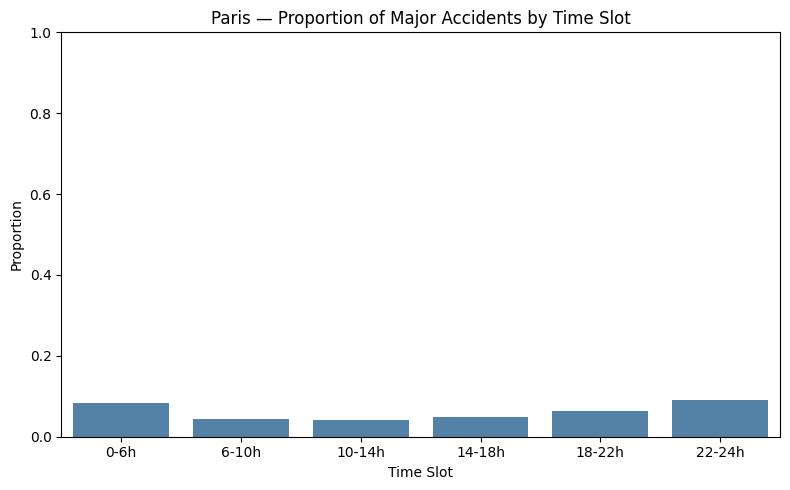

In [43]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=paris_df, x="time_slot", y="proportion", ax=ax, color="steelblue")
ax.set_title("Paris — Proportion of Major Accidents by Time Slot")
ax.set_xlabel("Time Slot")
ax.set_ylabel("Proportion")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

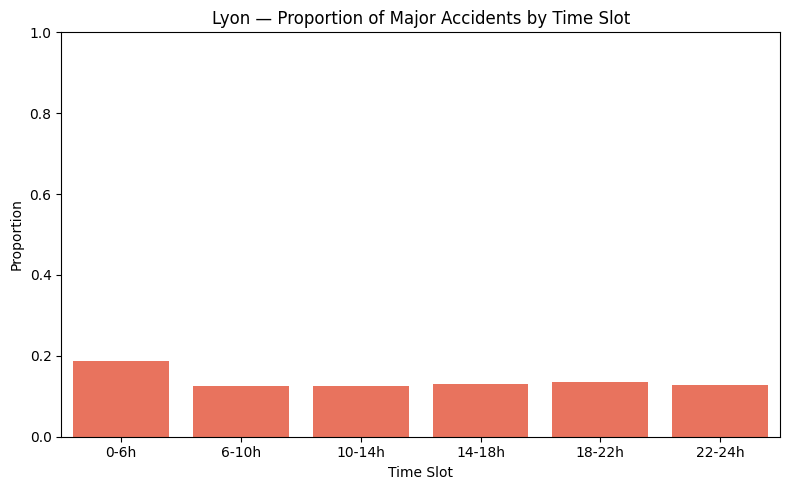

In [44]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=lyon_df, x="time_slot", y="proportion", ax=ax, color="tomato")
ax.set_title("Lyon — Proportion of Major Accidents by Time Slot")
ax.set_xlabel("Time Slot")
ax.set_ylabel("Proportion")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

In [45]:
paris_x = paris_df["time_slot"].astype(str).tolist()
paris_y = paris_df["proportion"].tolist()
lyon_x  = lyon_df["time_slot"].astype(str).tolist()
lyon_y  = lyon_df["proportion"].tolist()

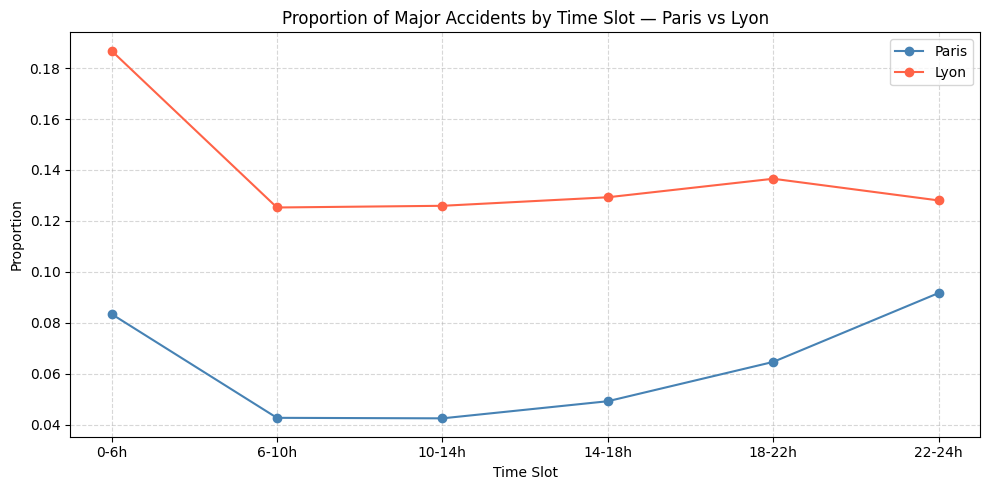

In [46]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(paris_x, paris_y, marker="o", label="Paris", color="steelblue")
ax.plot(lyon_x,  lyon_y,  marker="o", label="Lyon",  color="tomato")
ax.set_title("Proportion of Major Accidents by Time Slot — Paris vs Lyon")
ax.set_xlabel("Time Slot")
ax.set_ylabel("Proportion")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [64]:
paris_raw = df[df["city"] == "Paris"]
lyon_raw  = df[df["city"] == "Lyon"]

slot_0_6   = df[df["time_slot"] == "0-6h"]
slot_6_10  = df[df["time_slot"] == "6-10h"]
slot_10_14 = df[df["time_slot"] == "10-14h"]
slot_14_18 = df[df["time_slot"] == "14-18h"]
slot_18_22 = df[df["time_slot"] == "18-22h"]
slot_22_24 = df[df["time_slot"] == "22-24h"]

for slot_df, slot_name in [
    (slot_0_6,   "0-6h"),
    (slot_6_10,  "6-10h"),
    (slot_10_14, "10-14h"),
    (slot_14_18, "14-18h"),
    (slot_18_22, "18-22h"),
    (slot_22_24, "22-24h")
]:
    contingency = pd.crosstab(slot_df["city"], slot_df["severity"])
    chi2, p, _, _ = st.chi2_contingency(contingency)
    sig = "yes" if p < 0.05 else "no"
    print(f"{slot_name:<10} / {chi2:>8.3f} / {p:>12} / {sig:>8}")

0-6h       /   32.380 / 1.2676715199317525e-08 /      yes
6-10h      /   63.755 / 1.408965978967309e-15 /      yes
10-14h     /   79.222 / 5.550121215039172e-19 /      yes
14-18h     /   88.681 / 4.6385195839426835e-21 /      yes
18-22h     /   55.354 / 1.0064020297644846e-13 /      yes
22-24h     /    2.591 / 0.10746359024762103 /       no
